# Analista de Marketing i Estratégia Comercial: 06/07/2026
Quines característiques dels allotjaments
(equipaments, capacitat i ubicació) estan més relacionades amb els preus a cada ciutat?

## Análisis explicativo del precio — Fase 1 (Global) y Fase 2 (por ciudad)

Objetivo: cuantificar el peso de la capacidad, los equipamientos y la ciudad sobre
el precio de los alojamientos, mediante regresión lineal múltiple (MCO) sobre log(precio).

Enfoque explicativo, no predictivo. Punto de partida: dataset ya transformado
(flags de amenities por categoría, `logp` calculado). Los nulos de `price`/`accommodates`
y los duplicados de `apartment_id` se resuelven **dentro de este notebook** (decisión D6).

# Configuración del Entorno y Librerías
En este primer paso técnico, cargaremos las librerías necesarias para la manipulación de datos, la modelización econométrica mediante Mínimos Cuadrados Ordinarios (MCO) y la aplicación de los parches de robustez matemática para los contrastes.

* `pandas` y `numpy`: Para la carga de datos, limpieza de strings y transformaciones logarítmicas.
* `statsmodels`: Herramienta principal para ejecutar la regresión lineal múltiple y obtener los estadísticos de validación (R², p-valores y coeficientes).
* `scipy.stats`: Para las pruebas complementarias de distribución y diagnóstico de residuos.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 0. Carga del dataset transformado

Se importa **`Data/clean_dataset_06_07_2026.csv`**, que la fase de *Data Transformation* ha
enriquecido y sobrescrito: ya trae las 7 categorías de amenities como flags binarios `cat_*` y
`logp` calculado. Verificación rápida de dimensiones y de que las columnas esperadas
(`accommodates`, las 7 categorías, `city`, `logp`) están presentes antes de modelar.

In [2]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''Encuentra la carpeta raíz del proyecto subiendo desde el directorio actual.'''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}")

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'clean_dataset_06_07_2026.csv'
print(f"Ruta resuelta: {ruta}")

df_original = pd.read_csv(ruta, parse_dates=['insert_date'])
df = df_original.copy()
print("Dimensiones:", df.shape)

Ruta resuelta: E:\informacion y documentos\Curso analisis de datos IT Academy\Simulador empresarial\ProjecteData\Equip_34\Data\clean_dataset_06_07_2026.csv
Dimensiones: (7693, 54)


In [3]:
catcols = [c for c in df.columns if c.startswith('cat_')]
esperadas = ['accommodates', 'city', 'logp', 'price_€', 'apartment_id', 'insert_date'] + catcols
faltan = [c for c in esperadas if c not in df.columns]
print("Categorías de amenities (bloque de equipamientos):", catcols)
print("Columnas esperadas que faltan:", faltan if faltan else "ninguna ✓")
df[['apartment_id', 'city', 'accommodates', 'price_€', 'logp'] + catcols].head()

Categorías de amenities (bloque de equipamientos): ['cat_premium', 'cat_confort', 'cat_conectividad', 'cat_familia', 'cat_seguridad', 'cat_parking', 'cat_cocina']
Columnas esperadas que faltan: ninguna ✓


,apartment_id,city,accommodates,price_€,logp,cat_premium,cat_confort,cat_conectividad,cat_familia,cat_seguridad,cat_parking,cat_cocina
0,15695052,Barcelona,1,350.0,5.857933,1,1,1,0,0,0,1
1,14999488,Barcelona,2,250.0,5.521461,0,1,1,1,1,0,1
2,12265320,Barcelona,2,650.0,6.476972,0,1,1,0,0,0,1
3,16272738,Barcelona,2,760.0,6.633318,0,1,1,1,1,0,1
4,16262996,Barcelona,2,350.0,5.857933,0,0,1,0,1,0,1


## 1. Diagnóstico previo de los supuestos del modelo

Antes de ajustar cualquier regresión, se comprueba que los supuestos básicos de MCO
se sostienen sobre estos datos:
- Asimetría de `price` vs `logp` (para confirmar que el log corrige el sesgo).
- Multicolinealidad entre predictoras (VIF).
- Verificación de que no quedan duplicados de `apartment_id` que rompan la independencia de observaciones.

Como paso previo (secciones 1.1 y 1.2) se depuran nulos y duplicados **sólo sobre la copia de trabajo
de este análisis**; el diagnóstico numérico se realiza ya sobre datos depurados (sección 1.3).

## 1.1 Tratamiento de nulos en variables críticas

Se eliminan los registros con `price_€` o `accommodates` nulo (159 nulos de precio en el CSV limpio).
No se imputan, al ser las dos variables centrales del análisis explicativo — imputar aquí introduciría
sesgo directo en los coeficientes. Esta eliminación se hace una única vez, aquí, antes de la Fase 1 y la Fase 2.

In [4]:
n0 = len(df)
df = df.dropna(subset=['price_€', 'accommodates']).copy()
print(f"Filas: {n0} -> {len(df)}  (eliminados {n0 - len(df)} registros con price_€/accommodates nulo)")

Filas: 7693 -> 7534  (eliminados 159 registros con price_€/accommodates nulo)


## 1.2 Verificación y resolución de duplicados de `apartment_id`

Se confirma si existen duplicados de `apartment_id`. De existir, se conserva un único registro por
alojamiento (último snapshot según `insert_date`), para garantizar independencia de observaciones.

In [5]:
dups = int(df['apartment_id'].duplicated().sum())
print("Duplicados de apartment_id:", dups)
if dups > 0:
    df = (df.sort_values('insert_date')
            .drop_duplicates(subset='apartment_id', keep='last')
            .reset_index(drop=True))
    print("Resueltos ->", len(df), "filas.")
else:
    print("No hay duplicados (ya resueltos en Data Cleaning). apartment_id único:",
          df['apartment_id'].is_unique)

Duplicados de apartment_id: 0
No hay duplicados (ya resueltos en Data Cleaning). apartment_id único: True


### 1.3 Diagnóstico numérico: asimetría, multicolinealidad y prevalencia

Con los datos ya depurados se verifica que el `log` corrige el sesgo del precio, que no hay
multicolinealidad relevante (VIF) y —**añadido en la revisión**— la **prevalencia** de cada flag de
amenity. Una categoría casi universal (>95 %) o casi ausente (<5 %) aporta poca información: su
coeficiente se estima con muy pocos casos en el grupo minoritario, es inestable y **su signo no debe
sobre-interpretarse** (aunque salga "significativo" por el gran tamaño muestral).

In [6]:
skew_price = stats.skew(df['price_€'])
skew_logp = stats.skew(df['logp'])
print(f"Asimetría price_€ -> logp:  {skew_price:.2f} -> {skew_logp:.2f}  (el log simetriza)")

Xv = sm.add_constant(df[['accommodates'] + catcols])
vif = pd.DataFrame({'variable': Xv.columns,
                    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]})
print("\nVIF (excluida la constante):")
print(vif[vif['variable'] != 'const'].round(2).to_string(index=False))
print("VIF máximo:", round(vif.loc[vif['variable'] != 'const', 'VIF'].max(), 2),
      "-> sin multicolinealidad relevante")

# [REVISIÓN] Prevalencia de los flags: detecta categorías casi constantes (poco informativas).
# Umbral en 95%/5%: por debajo aún quedan cientos de casos en el grupo minoritario (estimable).
prev = df[catcols].mean().sort_values(ascending=False)
casi_universal = prev[(prev > 0.95) | (prev < 0.05)].index.tolist()
print("\nPrevalencia de cada categoría (% de alojamientos que la tienen):")
print((prev * 100).round(1).to_string())
print("\n[AVISO] Casi universales (>95%) o casi ausentes (<5%) -> coeficiente poco fiable, no leer el signo:",
      [c.replace('cat_', '') for c in casi_universal] or "ninguna")

Asimetría price_€ -> logp:  2.08 -> 0.07  (el log simetriza)

VIF (excluida la constante):
        variable  VIF
    accommodates 1.32
     cat_premium 1.26
     cat_confort 1.08
cat_conectividad 1.10
     cat_familia 1.22
   cat_seguridad 1.08
     cat_parking 1.21
      cat_cocina 1.11
VIF máximo: 1.32 -> sin multicolinealidad relevante

Prevalencia de cada categoría (% de alojamientos que la tienen):
cat_conectividad    98.6
cat_cocina          95.8
cat_confort         90.6
cat_familia         61.2
cat_parking         52.8
cat_premium         51.9
cat_seguridad       51.7

[AVISO] Casi universales (>95%) o casi ausentes (<5%) -> coeficiente poco fiable, no leer el signo: ['conectividad', 'cocina']


## 2. Fase 1 — Modelo Global (ciudad como variable de control)

Se ajusta un único modelo de regresión múltiple sobre todo el dataset:
`log(precio) ~ capacidad + categorías de equipamientos + ciudad (dummies)`

Aquí la ciudad se incluye como variable de control, no como segmentación: el objetivo es aislar el
efecto neto de capacidad y equipamientos evitando que una ciudad cara infle artificialmente esos
coeficientes. Se usan errores estándar robustos (**HC3**) para corregir la heterocedasticidad.

In [7]:
formula1 = "logp ~ accommodates + " + " + ".join(catcols) + " + C(city)"
m1 = smf.ols(formula1, data=df).fit(cov_type="HC3")
# [REVISIÓN] Se reporta también R² AJUSTADO (penaliza el nº de predictores; más honesto que el R² bruto)
print(f"Fase 1 · R² = {m1.rsquared:.3f} · R²_ajustado = {m1.rsquared_adj:.3f} · "
      f"n = {int(m1.nobs)} · nº predictores = {int(m1.df_model)}")
print(formula1)

Fase 1 · R² = 0.495 · R²_ajustado = 0.494 · n = 7534 · nº predictores = 15
logp ~ accommodates + cat_premium + cat_confort + cat_conectividad + cat_familia + cat_seguridad + cat_parking + cat_cocina + C(city)


## 3. Fase 1 — Lectura de resultados del modelo global

Interpretación de los coeficientes:
- **β estandarizados** (comparables entre sí) de `accommodates` y de cada categoría de equipamientos.
- **Significatividad** estadística de cada término (p-valor con HC3).
- Efecto de la **ciudad** respecto a la de referencia (dummy base).

Responde a "en promedio, en toda España, qué pesa más" — todavía no a "en cada ciudad" (Fase 2).

In [8]:
from statsmodels.stats.multitest import multipletests

# β estandarizados: se estandariza logp y las predictoras para que los coeficientes sean comparables
z = df.copy()
for c in ['logp', 'accommodates'] + catcols:
    sd = z[c].std()
    z[c] = (z[c] - z[c].mean()) / sd if sd > 0 else 0.0
mz = smf.ols(formula1, data=z).fit(cov_type="HC3")   # HC3 por coherencia (no altera los β puntuales)

idx = ['accommodates'] + catcols
# [REVISIÓN] Se añaden IC95% (HC3) y p-valores ajustados por Benjamini-Hochberg (FDR): se contrastan
# 8 coeficientes a la vez, así que conviene controlar los falsos positivos por comparación múltiple.
ci = m1.conf_int().loc[idx]
p_raw = m1.pvalues[idx]
p_bh = multipletests(p_raw.values, method='fdr_bh')[1]
tabla = pd.DataFrame({
    "beta_std": mz.params[idx].round(3),
    "coef_log": m1.params[idx].round(3),
    "IC95_low": ci[0].round(3),
    "IC95_high": ci[1].round(3),
    "p_value": p_raw.round(4),
    "p_BH": np.round(p_bh, 4),
})
tabla["signif_BH"] = np.where(tabla["p_BH"] < 0.05, "sí", "no")
print("Fase 1 — coeficientes (β estandarizado, coef. log, IC95% HC3, p ajustado BH), por |β|:")
tabla.reindex(tabla["beta_std"].abs().sort_values(ascending=False).index)

Fase 1 — coeficientes (β estandarizado, coef. log, IC95% HC3, p ajustado BH), por |β|:


,beta_std,coef_log,IC95_low,IC95_high,p_value,p_BH,signif_BH
accommodates,0.559,0.170,0.162,0.178,0.0000,0.0000,sí
cat_familia,0.094,0.145,0.116,0.174,0.0000,0.0000,sí
cat_premium,0.067,0.101,0.072,0.131,0.0000,0.0000,sí
cat_confort,0.064,0.165,0.120,0.209,0.0000,0.0000,sí
cat_seguridad,-0.029,-0.043,-0.069,-0.017,0.0011,0.0018,sí
cat_cocina,0.028,0.105,0.035,0.175,0.0035,0.0046,sí
cat_conectividad,-0.025,-0.160,-0.281,-0.038,0.0099,0.0113,sí
cat_parking,-0.018,-0.027,-0.055,-0.000,0.0491,0.0491,sí


In [9]:
# [REVISIÓN] Se declara EXPLÍCITAMENTE la ciudad de referencia (base de las dummies): statsmodels usa
# la primera alfabéticamente. Todos los efectos_% son RELATIVOS a esa ciudad.
ref_city = sorted(df['city'].unique())[0]
print("Ciudad de referencia (base de las dummies):", ref_city, "\n")

# Efecto de la ciudad, en % sobre el precio, respecto a la ciudad de referencia
city_terms = [p for p in m1.params.index if p.startswith("C(city)")]
efecto_city = pd.DataFrame({
    "coef_log": m1.params[city_terms].round(3),
    "efecto_%_vs_ref": ((np.exp(m1.params[city_terms]) - 1) * 100).round(1),
    "p_value": m1.pvalues[city_terms].round(4)
}).sort_values("efecto_%_vs_ref", ascending=False)
efecto_city.index = [ix.replace('C(city)[T.', '').replace(']', '') for ix in efecto_city.index]
print(f"Efecto de cada ciudad respecto a {ref_city} (base):")
efecto_city

Ciudad de referencia (base de las dummies): Barcelona 

Efecto de cada ciudad respecto a Barcelona (base):


,coef_log,efecto_%_vs_ref,p_value
Mallorca,0.241,27.2,0.0000
Menorca,0.186,20.5,0.0000
Sevilla,0.015,1.5,0.6584
Girona,-0.029,-2.8,0.1839
Madrid,-0.081,-7.8,0.0000
Málaga,-0.188,-17.2,0.0000
Valencia,-0.277,-24.2,0.0000


## 4. Fase 1 — Contribución de cada bloque a la varianza del precio

**[Revisión metodológica]** En la versión anterior el reparto se hacía con **η² de Tipo-II**, cuyo
denominador (suma de sumas de cuadrados Tipo-II + residual) **no particiona limpiamente la varianza
total** cuando los predictores están correlacionados; los "%" resultantes no eran un reparto exacto.

Se sustituye por la **contribución única de cada bloque = ΔR²** (varianza *semiparcial*): el descenso
del R² al **retirar ese bloque** del modelo completo. Es el % de varianza que **solo** ese bloque
explica. Como los bloques comparten varianza, **no suman el R² total**; la diferencia es la
*varianza compartida*. Es la lectura correcta y honesta de "peso de cada bloque".

In [10]:
def r2_de(formula):
    return smf.ols(formula, data=df).fit().rsquared

m1_ols = smf.ols(formula1, data=df).fit()
r2_full = m1_ols.rsquared
base_terms = {'capacidad': 'accommodates',
              'amenities (bloque)': ' + '.join(catcols),
              'ciudad': 'C(city)'}

def formula_sin(bloque):
    return "logp ~ " + " + ".join(t for k, t in base_terms.items() if k != bloque)

print(f"R² del modelo completo: {r2_full:.3f}   (R²_ajustado {m1_ols.rsquared_adj:.3f})\n")
print("Contribución ÚNICA de cada bloque (ΔR² al retirarlo; % de varianza que SOLO él aporta):")
contrib = {}
for bloque in base_terms:
    contrib[bloque] = r2_full - r2_de(formula_sin(bloque))
    print(f"   {bloque:22s}: {100 * contrib[bloque]:5.2f} %")
compartida = r2_full - sum(contrib.values())
print(f"\n   Varianza COMPARTIDA entre bloques (no atribuible a uno solo): {100 * compartida:5.2f} %")
print(f"   Varianza NO explicada por el modelo:                          {100 * (1 - r2_full):5.1f} %")

R² del modelo completo: 0.495   (R²_ajustado 0.494)

Contribución ÚNICA de cada bloque (ΔR² al retirarlo; % de varianza que SOLO él aporta):
   capacidad             : 21.58 %


   amenities (bloque)    :  1.73 %
   ciudad                :  2.68 %

   Varianza COMPARTIDA entre bloques (no atribuible a uno solo): 23.50 %
   Varianza NO explicada por el modelo:                           50.5 %


## 5. Fase 2 — Modelos locales (uno por ciudad)

Se ajusta un modelo independiente por ciudad: `log(precio) ~ capacidad + categorías de equipamientos`.
Aquí la ciudad ya no es control sino **segmentación**: cada modelo responde directamente a la pregunta
de negocio ("¿qué características pesan más en CADA ciudad?").

**[Revisión]** Por coherencia con la Fase 1, el peso de cada bloque se mide con la **contribución única
ΔR²** (semiparcial), no con η² Tipo-II. Se añade **R²_ajustado** (clave en ciudades pequeñas, donde 8
predictores inflan el R² bruto) y el **top_amenity solo se reporta si es estadísticamente significativo**
(p<0,05); si ninguna categoría lo es, se marca "—" para no destacar ruido.

In [11]:
formula2 = "logp ~ accommodates + " + " + ".join(catcols)
predictors = ['accommodates'] + catcols

def zscore(s):
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else s * 0.0

def r2_sub(formula, sub):
    return smf.ols(formula, data=sub).fit().rsquared

rows = []
beta_matrix = {}   # ciudad -> {predictor: beta_std}
for city, sub in df.groupby('city'):
    sub = sub.copy()
    m2 = smf.ols(formula2, data=sub).fit(cov_type="HC3")
    r2f = m2.rsquared
    # [REVISIÓN] contribución única (ΔR²) de capacidad y de amenities en esa ciudad
    uniq_cap = r2f - r2_sub("logp ~ " + " + ".join(catcols), sub)   # quitar capacidad
    uniq_amen = r2f - r2_sub("logp ~ accommodates", sub)            # quitar todas las amenities

    z2 = sub.copy()
    z2['logp'] = zscore(z2['logp'])
    for c in predictors:
        z2[c] = zscore(z2[c])
    mz2 = smf.ols(formula2, data=z2).fit(cov_type="HC3")
    betas = {p: mz2.params.get(p, np.nan) for p in predictors}
    pvals = {p: mz2.pvalues.get(p, np.nan) for p in predictors}
    beta_matrix[city] = betas

    # [REVISIÓN] top_amenity = mayor |β| SOLO entre las significativas (p<0.05); si ninguna -> '—'
    sig_cats = [c for c in catcols if pvals[c] < 0.05]
    top = max(sig_cats, key=lambda c: abs(betas[c])) if sig_cats else None
    rows.append(dict(ciudad=city, n=len(sub),
                     R2=round(r2f, 2), R2_aj=round(m2.rsquared_adj, 2),
                     uniq_cap=round(100 * uniq_cap, 1), uniq_amen=round(100 * uniq_amen, 1),
                     top_amenity=(top.replace('cat_', '') if top else '—'),
                     beta_top=(round(betas[top], 2) if top else np.nan)))

fase2 = pd.DataFrame(rows).sort_values("uniq_amen", ascending=False).reset_index(drop=True)
fase2

,ciudad,n,R2,R2_aj,uniq_cap,uniq_amen,top_amenity,beta_top
0,Menorca,161,0.50,0.48,32.8,6.9,confort,0.21
1,Málaga,393,0.30,0.29,17.8,5.3,familia,0.19
2,Sevilla,400,0.29,0.28,20.1,4.4,familia,0.12
3,Mallorca,1192,0.40,0.40,26.1,3.1,premium,0.15
4,Madrid,1623,0.41,0.40,24.7,3.0,familia,0.12
5,Barcelona,2227,0.45,0.45,24.5,2.5,familia,0.14
6,Valencia,357,0.41,0.40,28.2,2.1,confort,0.10
7,Girona,1181,0.36,0.35,28.7,1.9,premium,0.10


## 6. Fase 2 — Comparación entre ciudades

Peso relativo de **capacidad** frente al **bloque de equipamientos** en cada mercado local, normalizado
a 100 % sobre la suma de sus **contribuciones únicas ΔR²**. Se presta atención a los casos con n bajo
(Menorca, Valencia, Málaga, Sevilla), donde R² y coeficientes son menos fiables (ver R²_aj).

In [12]:
d = fase2.copy()
# [REVISIÓN] normalización sobre ΔR² únicos (no η²). tot puede ser 0 si el bloque no explica nada.
tot_uni = (d["uniq_cap"] + d["uniq_amen"]).replace(0, np.nan)
d["cap_%"] = (100 * d["uniq_cap"] / tot_uni).round(0)
d["amen_%"] = (100 - d["cap_%"]).round(0)
print("Peso relativo capacidad vs. equipamientos por ciudad (normalizado a 100% sobre ΔR² únicos):")
d[["ciudad", "n", "R2", "R2_aj", "uniq_cap", "uniq_amen", "cap_%", "amen_%", "top_amenity"]]

Peso relativo capacidad vs. equipamientos por ciudad (normalizado a 100% sobre ΔR² únicos):


,ciudad,n,R2,R2_aj,uniq_cap,uniq_amen,cap_%,amen_%,top_amenity
0,Menorca,161,0.50,0.48,32.8,6.9,83.0,17.0,confort
1,Málaga,393,0.30,0.29,17.8,5.3,77.0,23.0,familia
2,Sevilla,400,0.29,0.28,20.1,4.4,82.0,18.0,familia
3,Mallorca,1192,0.40,0.40,26.1,3.1,89.0,11.0,premium
4,Madrid,1623,0.41,0.40,24.7,3.0,89.0,11.0,familia
5,Barcelona,2227,0.45,0.45,24.5,2.5,91.0,9.0,familia
6,Valencia,357,0.41,0.40,28.2,2.1,93.0,7.0,confort
7,Girona,1181,0.36,0.35,28.7,1.9,94.0,6.0,premium


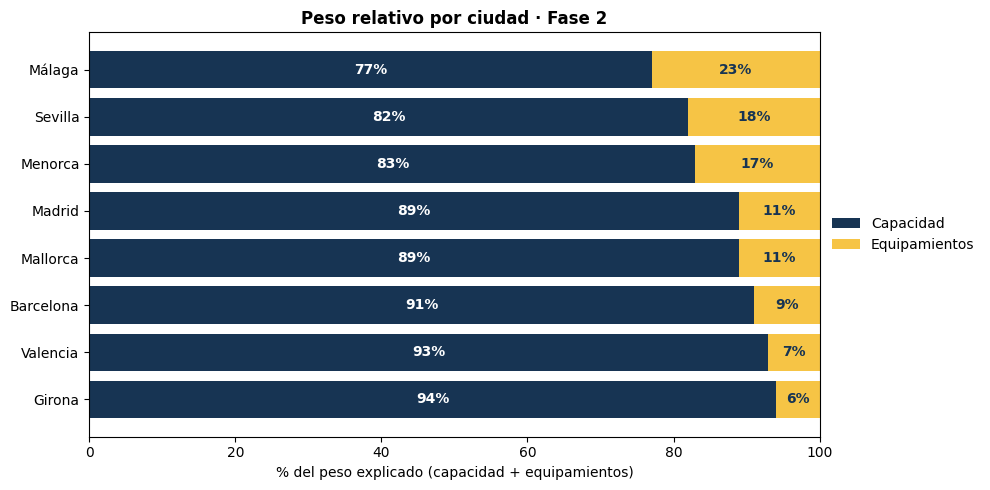

In [13]:
# Gráfico de barras apiladas: capacidad vs equipamientos por ciudad
NAVY, GREEN, YELLOW = "#173453", "#2F8F8F", "#F6C445"
dd = d.dropna(subset=["cap_%"]).sort_values("amen_%")   # [REVISIÓN] descarta ciudades sin ΔR² (por seguridad)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dd["ciudad"], dd["cap_%"], color=NAVY, label="Capacidad")
ax.barh(dd["ciudad"], dd["amen_%"], left=dd["cap_%"], color=YELLOW, label="Equipamientos")
for i, (_, r) in enumerate(dd.iterrows()):
    ax.text(r["cap_%"] / 2, i, f"{r['cap_%']:.0f}%", va="center", ha="center", color="white", fontweight="bold")
    ax.text(r["cap_%"] + r["amen_%"] / 2, i, f"{r['amen_%']:.0f}%", va="center", ha="center", color=NAVY, fontweight="bold")
ax.set_xlim(0, 100)
ax.set_xlabel("% del peso explicado (capacidad + equipamientos)")
ax.set_title("Peso relativo por ciudad · Fase 2", fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
(raiz_proyecto / 'Results').mkdir(exist_ok=True)
fig.savefig(raiz_proyecto / 'Results' / 'marketing_fase2_peso_por_ciudad.png', dpi=130, bbox_inches="tight")
plt.show()

## 7. Visualización — Heatmap característica × ciudad

Heatmap que resume la Fase 2: filas = características (capacidad + cada bloque de amenities),
columnas = ciudades, valores = **β estandarizado** de cada característica en el modelo local de esa
ciudad (efecto sobre el log-precio, comparable entre celdas). Es la pieza visual central del análisis.

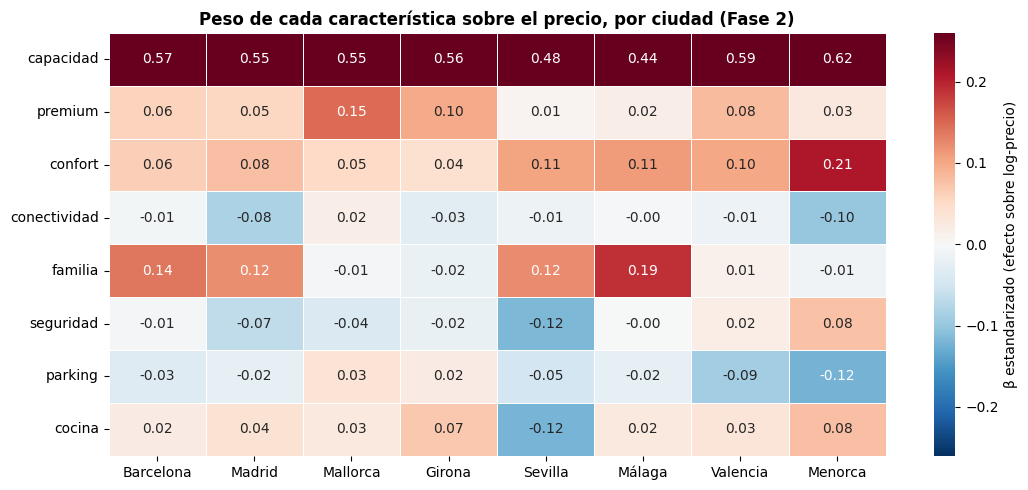

In [14]:
heat = pd.DataFrame(beta_matrix)            # index = predictores, columns = ciudades
heat.index = [ix.replace('cat_', '') if ix != 'accommodates' else 'capacidad' for ix in heat.index]
# ordenar columnas por tamaño de muestra (de mayor a menor) para lectura
orden_ciudades = fase2.sort_values('n', ascending=False)['ciudad'].tolist()
heat = heat[orden_ciudades]

# [REVISIÓN] La escala de color se acota al rango de las AMENITIES para que sus contrastes sean
# visibles; 'capacidad' (β≈0,5) satura a propósito, pero su valor queda anotado en la celda.
amen_abs = np.nanmax(np.abs(heat.drop(index='capacidad').values))
vlim = max(0.20, round(float(amen_abs) + 0.05, 2))
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-vlim, vmax=vlim,
            linewidths=.5, cbar_kws={"label": "β estandarizado (efecto sobre log-precio)"}, ax=ax)
ax.set_title("Peso de cada característica sobre el precio, por ciudad (Fase 2)", fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout()
fig.savefig(raiz_proyecto / 'Results' / 'marketing_heatmap_caracteristica_ciudad.png', dpi=130, bbox_inches="tight")
plt.show()

## 8. Validación de robustez

Chequeos finales sobre el modelo global:
- **Breusch-Pagan** para confirmar que los errores robustos (HC3) eran necesarios.
- Revisión de **residuos** (distribución y patrón vs. ajustados).
- Sensibilidad a **outliers**: se reajusta el modelo excluyendo el 1 % de precios más extremos,
  sólo como control (no como tratamiento), para comprobar que las conclusiones no cambian.

In [15]:
# Breusch-Pagan
bp_p = het_breuschpagan(m1.resid, m1.model.exog)[3]
jb = sm.stats.stattools.jarque_bera(m1.resid)
print(f"Breusch-Pagan p = {bp_p:.2e}  -> heterocedasticidad (por eso usamos HC3)")
print(f"Residuos: skew {jb[2]:.2f}  ·  kurtosis {jb[3]:.2f}")

# Sensibilidad a outliers (1% superior de precio)
umbral = df['price_€'].quantile(0.99)
m1_sens = smf.ols(formula1, data=df[df['price_€'] <= umbral]).fit(cov_type="HC3")
comp = pd.DataFrame({
    "beta_std_full": mz.params[['accommodates'] + catcols].round(3),
    "coef_full": m1.params[['accommodates'] + catcols].round(3),
    "coef_sin_top1%": m1_sens.params[['accommodates'] + catcols].round(3),
})
print(f"\nSensibilidad (excluyendo precios > {umbral:.0f} €, R² full {m1.rsquared:.3f} vs sin-top1% {m1_sens.rsquared:.3f}):")
comp

Breusch-Pagan p = 3.49e-11  -> heterocedasticidad (por eso usamos HC3)
Residuos: skew 0.15  ·  kurtosis 4.71

Sensibilidad (excluyendo precios > 4287 €, R² full 0.495 vs sin-top1% 0.494):


,beta_std_full,coef_full,coef_sin_top1%
accommodates,0.559,0.170,0.167
cat_premium,0.067,0.101,0.098
cat_confort,0.064,0.165,0.171
cat_conectividad,-0.025,-0.160,-0.179
cat_familia,0.094,0.145,0.146
cat_seguridad,-0.029,-0.043,-0.045
cat_parking,-0.018,-0.027,-0.025
cat_cocina,0.028,0.105,0.129


In [16]:
# [REVISIÓN] Chequeo de FORMA FUNCIONAL de la capacidad. No cambia el modelo principal (D3 fija
# accommodates lineal), sólo valida ese supuesto: se compara con un modelo que añade accommodates².
# Si el término cuadrático apenas aporta R², la aproximación lineal es adecuada para el fin explicativo.
m_lin = smf.ols(formula1, data=df).fit()
m_quad = smf.ols(formula1 + " + I(accommodates**2)", data=df).fit()
p_quad = m_quad.pvalues.get('I(accommodates ** 2)', np.nan)
dR2_quad = m_quad.rsquared - m_lin.rsquared
print(f"R² lineal = {m_lin.rsquared:.4f}   vs   R² con accommodates² = {m_quad.rsquared:.4f}   "
      f"(ΔR² = {dR2_quad:.4f})")
print(f"p-valor del término cuadrático: {p_quad:.4f}")
# [REVISIÓN] Mensaje dinámico y honesto (no hardcodeado): interpreta la magnitud real del ΔR².
if dR2_quad < 0.01:
    print("Lectura: ΔR² < 1 pp -> el supuesto lineal es plenamente adecuado.")
else:
    print(f"Lectura: ΔR² = {100*dR2_quad:.1f} pp y término cuadrático significativo -> existe una CURVATURA "
          f"leve (rendimientos DECRECIENTES en %: cada plaza extra sube el precio un porcentaje menor). "
          f"El modelo lineal mantiene válido el RANKING de importancia, pero una especificación "
          f"log(accommodates) captaría mejor esa curvatura -> se anota como mejora futura (ver limitaciones).")

R² lineal = 0.4949   vs   R² con accommodates² = 0.5191   (ΔR² = 0.0243)
p-valor del término cuadrático: 0.0000
Lectura: ΔR² = 2.4 pp y término cuadrático significativo -> existe una CURVATURA leve (rendimientos DECRECIENTES en %: cada plaza extra sube el precio un porcentaje menor). El modelo lineal mantiene válido el RANKING de importancia, pero una especificación log(accommodates) captaría mejor esa curvatura -> se anota como mejora futura (ver limitaciones).


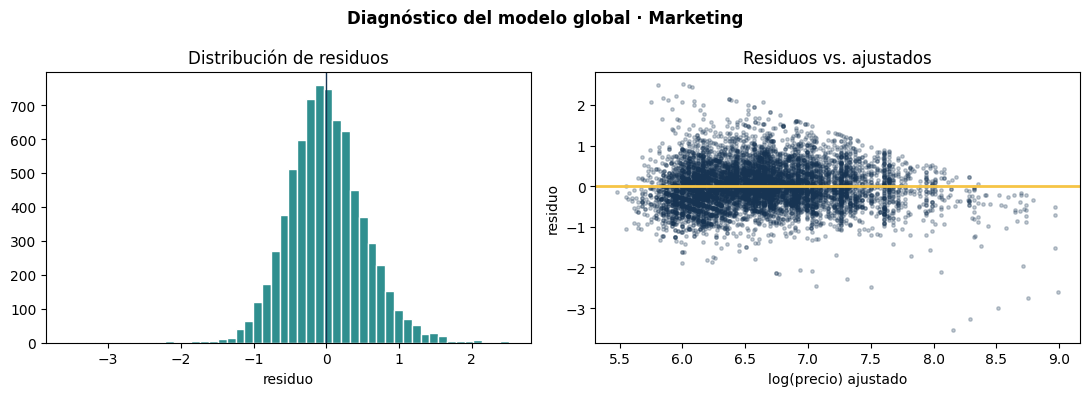

In [17]:
# Diagnóstico visual de residuos
NAVY, GREEN, YELLOW = "#173453", "#2F8F8F", "#F6C445"
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(m1.resid, bins=50, color=GREEN, edgecolor="white"); ax[0].axvline(0, color=NAVY, lw=1)
ax[0].set_title("Distribución de residuos"); ax[0].set_xlabel("residuo")
ax[1].scatter(m1.fittedvalues, m1.resid, s=6, alpha=.25, color=NAVY); ax[1].axhline(0, color=YELLOW, lw=2)
ax[1].set_title("Residuos vs. ajustados"); ax[1].set_xlabel("log(precio) ajustado"); ax[1].set_ylabel("residuo")
fig.suptitle("Diagnóstico del modelo global · Marketing", fontweight="bold")
fig.tight_layout()
fig.savefig(raiz_proyecto / 'Results' / 'marketing_fase1_diagnostico_residuos.png', dpi=130)
plt.show()

## 9. Conclusiones del análisis

Resumen dinámico de los hallazgos, generado a partir de los resultados ejecutados arriba.

In [18]:
# [REVISIÓN] Con n grande casi TODAS las categorías salen significativas; el titular se construye por
# TAMAÑO DE EFECTO (|β estandarizado|), no por el p-valor, y las cifras de peso usan ΔR² único (§4/§5).
# Además, las categorías casi universales (detectadas en §1.3) se excluyen de "con peso" aunque tengan β.
UMBRAL = 0.05
cats_orden = tabla.loc[catcols].sort_values('beta_std', ascending=False)
con_peso = [ix.replace('cat_', '') for ix in cats_orden.index
            if cats_orden.loc[ix, 'beta_std'] >= UMBRAL and ix not in casi_universal]
marginales = [ix.replace('cat_', '') for ix in cats_orden.index
              if ix.replace('cat_', '') not in con_peso]
mas_amen = fase2.sort_values('uniq_amen', ascending=False).iloc[0]
menos_amen = fase2.sort_values('uniq_amen').iloc[0]

print("=== TITULARES DEL ANÁLISIS ===\n")
print(f"1. La CAPACIDAD (accommodates) domina el precio: β_std={tabla.loc['accommodates','beta_std']:.2f}; "
      f"contribución única ΔR²={100*contrib['capacidad']:.1f}% de la varianza.")
print(f"2. Los EQUIPAMIENTOS van 2º (contribución única ΔR²={100*contrib['amenities (bloque)']:.1f}%). "
      f"Con peso apreciable (β_std≥{UMBRAL}): {', '.join(con_peso) or 'ninguna'}.")
print(f"   Casi universales / sin poder discriminante: {', '.join(marginales)} "
      f"(algunas significativas por el gran n, pero con efecto ~0 o prevalencia >90%).")
print(f"3. La CIUDAD pesa sobre todo ENTRE mercados (ΔR²={100*contrib['ciudad']:.1f}%; nivel de precio), no dentro.")
print(f"4. Los equipamientos pesan más en {mas_amen['ciudad']} (ΔR²_amen {mas_amen['uniq_amen']}%) "
      f"y menos en {menos_amen['ciudad']} (ΔR²_amen {menos_amen['uniq_amen']}%).")
print(f"5. Supuestos OK: log corrige asimetría ({stats.skew(df['price_€']):.2f}->{stats.skew(df['logp']):.2f}); "
      f"VIF bajo; HC3 por heterocedasticidad (BP p={bp_p:.1e}); R² {r2_full:.3f} (aj {m1.rsquared_adj:.3f}).")

=== TITULARES DEL ANÁLISIS ===

1. La CAPACIDAD (accommodates) domina el precio: β_std=0.56; contribución única ΔR²=21.6% de la varianza.
2. Los EQUIPAMIENTOS van 2º (contribución única ΔR²=1.7%). Con peso apreciable (β_std≥0.05): familia, premium, confort.
   Casi universales / sin poder discriminante: cocina, parking, conectividad, seguridad (algunas significativas por el gran n, pero con efecto ~0 o prevalencia >90%).
3. La CIUDAD pesa sobre todo ENTRE mercados (ΔR²=2.7%; nivel de precio), no dentro.
4. Los equipamientos pesan más en Menorca (ΔR²_amen 6.9%) y menos en Girona (ΔR²_amen 1.9%).
5. Supuestos OK: log corrige asimetría (2.08->0.07); VIF bajo; HC3 por heterocedasticidad (BP p=3.5e-11); R² 0.495 (aj 0.494).


### Respuesta a la pregunta de negocio y limitaciones

**¿Qué características están más relacionadas con el precio en cada ciudad?**
- **La capacidad (`accommodates`) es, con diferencia, el principal factor** en todas las ciudades.
- **Los equipamientos son el segundo factor y su peso varía por ciudad** (ver heatmap y barras): las
  categorías con peso apreciable son las de valor añadido (**familia, premium, confort**), mientras
  que las casi universales (**conectividad, cocina, parking, seguridad**) apenas discriminan precio
  (efecto ~0, aunque salgan significativas por el gran tamaño muestral).
- **La ubicación (ciudad) explica el precio sobre todo *entre* mercados** (nivel general de precios),
  más que *dentro* de cada ciudad.

**Limitaciones (según la justificación técnica):**
- El modelo muestra **asociación controlada, no causalidad**: añadir un extra no garantiza una subida
  automática de precio.
- El **R² es parcial**: el alcance se acota deliberadamente a las 4 variables acordadas
  (`price`, `accommodates`, `city`, `amenities_list`); el resto de la varianza corresponde a factores
  no incluidos.
- **Fiabilidad menor en ciudades de muestra pequeña** (Menorca, Valencia, Málaga, Sevilla): interpretar
  con el **R²_ajustado**, no el R² bruto.
- `neighbourhood_district` está todo nulo en varias ciudades, por lo que **no se modela la ubicación
  intra-ciudad**.
- **Rendimientos decrecientes de la capacidad** (detectado en §8): `accommodates` tiene una leve
  curvatura (el término cuadrático añade ~2 pp de R²). El modelo lineal mantiene el ranking, pero el
  aumento **porcentual** del precio por cada plaza extra disminuye (en euros el salto crece); una
  especificación `log(accommodates)` lo capturaría mejor.
- **Variables casi universales** (`conectividad`, `cocina`): su coeficiente es poco fiable por baja
  varianza; no debe leerse su signo como una relación real con el precio.

**Mejoras futuras:** ampliar variables (reseñas, estacionalidad, ubicación intra-ciudad), usar
`log(accommodates)` para la curvatura, y evolucionar a un **modelo multinivel** (efectos aleatorios por
ciudad) en lugar de fragmentar la muestra.